# Insite to ObsPy and Snuffler

In [17]:
from pathlib import Path
import sys

for candidate in (Path.cwd(), Path.cwd() / 'richter' / 'insite2obspy'):
    if (candidate / 'insitedata2snuffler.py').exists():
        sys.path.insert(0, str(candidate))
        break

import numpy as np
from obspy import read_events, read_inventory, Trace, UTCDateTime
from obspy.signal.trigger import classic_sta_lta, plot_trigger
from pyrocko import obspy_compat

from insitedata2snuffler import (
    get_high_precision_events,
    build_master_stream,
    build_station_channel_map
)

obspy_compat.plant()

In [18]:
experiment = 'm0013'
metadata_root = '../../data'
# data_root = f'/mnt/hphtfear/{experiment}/'  
data_root = rf'\\hphtfear\hphtfear\{experiment}'  # Windows UNC example

metadataFolder = Path(metadata_root) / experiment / 'ae' / 'red'
event_xml_path = metadataFolder / f'{experiment} event data.xml'
station_xml_path = metadataFolder / f'{experiment}.xml'

# questo dovrebbe richiamare la funzione di events_csv2quakeml.py
obspy_catalog = read_events(str(event_xml_path), format='QUAKEML')
pyrocko_events = get_high_precision_events(obspy_catalog)

# questo dovrebbe richiamare la funzione di stations_csv2stationxml.py
obspy_inventory = read_inventory(str(station_xml_path), format='STATIONXML')
station_channel_map = build_station_channel_map(obspy_inventory)
pyrocko_stations = obspy_inventory.to_pyrocko_stations()

master_stream = build_master_stream(data_root, station_channel_map=station_channel_map)
target_time = pyrocko_events[0].time
print(master_stream)
print(target_time)


--- 🔍 Searching for Data Waveforms ---
Found 7 SRM files. Assembling master stream...
Loading: richter-m.m0013.00001.srm | Start: 2025-04-03T12:18:19.009000Z
Loading: richter-m.m0013.00002.srm | Start: 2025-04-03T12:28:19.189000Z
Loading: richter-m.m0013.00003.srm | Start: 2025-04-03T12:38:19.380000Z
Loading: richter-m.m0013.00004.srm | Start: 2025-04-03T12:48:19.556000Z
Loading: richter-m.m0013.00005.srm | Start: 2025-04-03T12:58:19.747000Z
Loading: richter-m.m0013.00006.srm | Start: 2025-04-03T13:08:19.938000Z
Loading: richter-m.m0013.00007.srm | Start: 2025-04-03T13:18:20.112000Z
28 Trace(s) in Stream:

RC.S01.RAW.NDZ | 2025-04-03T12:18:19.009000Z - 2025-04-03T12:28:19.187688Z | 10000000.0 Hz, 6001786879 samples
...
(26 other traces)
...
RC.S04.RAW.NDZ | 2025-04-03T13:18:20.112000Z - 2025-04-03T13:27:31.977549Z | 10000000.0 Hz, 5518655487 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]
1743683320.3806407


In [19]:
from obspy import Stream

def trace_window(stream, target_time, pre_seconds=1.0, post_seconds=1.0):
    if not isinstance(target_time, UTCDateTime):
        target_time = UTCDateTime(target_time)

    windowed = Stream()
    for tr in stream:
        if not (tr.stats.starttime <= target_time <= tr.stats.endtime):
            continue

        start_idx = int(round((target_time - pre_seconds - tr.stats.starttime) * tr.stats.sampling_rate))
        start_idx = max(0, start_idx)
        npts = int(round((pre_seconds + post_seconds) * tr.stats.sampling_rate))
        end_idx = min(len(tr.data), start_idx + npts)

        print(f'Selected trace: {tr.id} | {tr.stats.starttime} -> {tr.stats.endtime}')
        windowed.append(Trace(
            data=tr.data[start_idx:end_idx],
            header={
                'network': tr.stats.network,
                'station': tr.stats.station,
                'location': tr.stats.location,
                'channel': tr.stats.channel,
                'sampling_rate': tr.stats.sampling_rate,
                'starttime': tr.stats.starttime + start_idx * tr.stats.delta,
            },
        ))

    return windowed

def stream_window(stream, starttime, endtime):
    if not isinstance(starttime, UTCDateTime):
        starttime = UTCDateTime(starttime)
    if not isinstance(endtime, UTCDateTime):
        endtime = UTCDateTime(endtime)

    windowed = Stream()
    for tr in stream:
        if tr.stats.endtime < starttime or tr.stats.starttime > endtime:
            continue

        start_idx = int(round((starttime - tr.stats.starttime) * tr.stats.sampling_rate))
        start_idx = max(0, start_idx)
        end_idx = int(round((endtime - tr.stats.starttime) * tr.stats.sampling_rate)) + 1
        end_idx = min(len(tr.data), end_idx)

        windowed.append(Trace(
            data=tr.data[start_idx:end_idx],
            header={
                'network': tr.stats.network,
                'station': tr.stats.station,
                'location': tr.stats.location,
                'channel': tr.stats.channel,
                'sampling_rate': tr.stats.sampling_rate,
                'starttime': tr.stats.starttime + start_idx * tr.stats.delta,
            },
        ))

    return windowed

In [20]:
def pipeline(stream, target_time, show_plots=True, show_spectrogram=True):
    window = trace_window(stream, target_time, pre_seconds=0.01, post_seconds=0.01)
    if len(window) == 0:
        raise ValueError('No traces found in the requested window')
    trace = window[0]
    
    if show_plots:
        trace.plot(method='full', color='k')
    if show_spectrogram:
        trace.spectrogram(dbscale=True)

    trace.detrend('linear')
    trace.detrend('demean')
    trace.filter('bandpass',freqmin=100000,freqmax=4_500_000, corners=4, zerophase=True)

    if show_plots:
        trace.plot(method='full', color='k')
    if show_spectrogram:
        trace.spectrogram(dbscale=True)
    
    return trace

In [21]:
analysis_stream = trace_window(master_stream, target_time, pre_seconds=0.01, post_seconds=0.01)
analysis_trace = analysis_stream[0]
print(analysis_stream)
print(analysis_trace)

Selected trace: RC.S01.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z
Selected trace: RC.S02.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z
Selected trace: RC.S03.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z
Selected trace: RC.S04.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z
4 Trace(s) in Stream:
RC.S01.RAW.NDZ | 2025-04-03T12:28:40.370641Z - 2025-04-03T12:28:40.390641Z | 10000000.0 Hz, 200000 samples
RC.S02.RAW.NDZ | 2025-04-03T12:28:40.370641Z - 2025-04-03T12:28:40.390641Z | 10000000.0 Hz, 200000 samples
RC.S03.RAW.NDZ | 2025-04-03T12:28:40.370641Z - 2025-04-03T12:28:40.390641Z | 10000000.0 Hz, 200000 samples
RC.S04.RAW.NDZ | 2025-04-03T12:28:40.370641Z - 2025-04-03T12:28:40.390641Z | 10000000.0 Hz, 200000 samples
RC.S01.RAW.NDZ | 2025-04-03T12:28:40.370641Z - 2025-04-03T12:28:40.390641Z | 10000000.0 Hz, 200000 samples


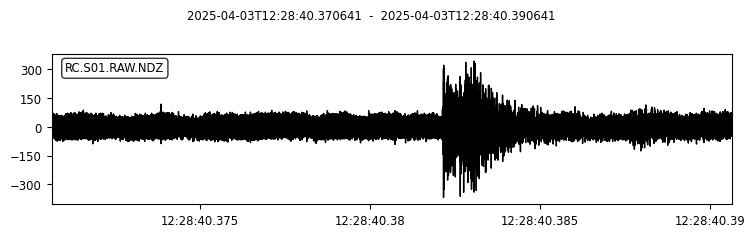

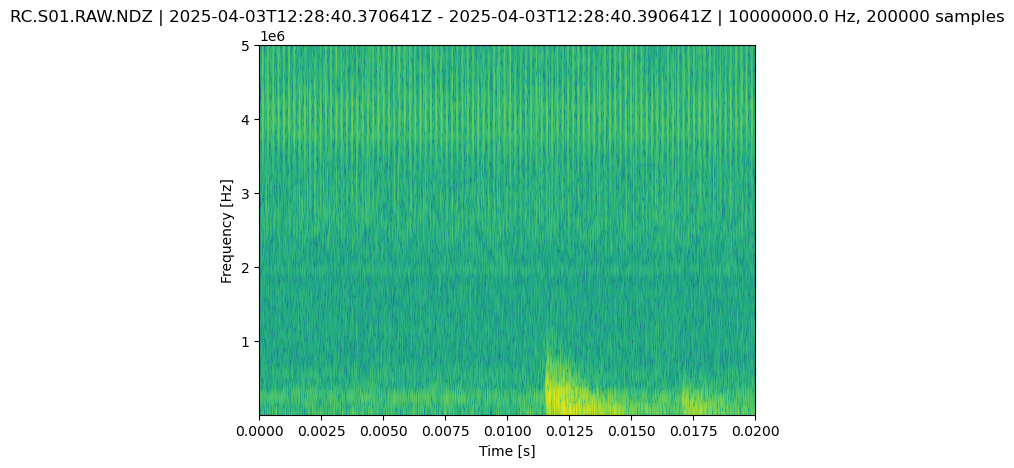

In [22]:
%matplotlib inline

analysis_trace_plot = analysis_trace.copy()
analysis_trace_plot.detrend('linear')
analysis_trace_plot.detrend('demean')
analysis_trace_plot.plot(method='full', color='k')

analysis_trace.decimate(1, no_filter=True)
analysis_trace.spectrogram(dbscale=True)

tentativo con demean, lowpass

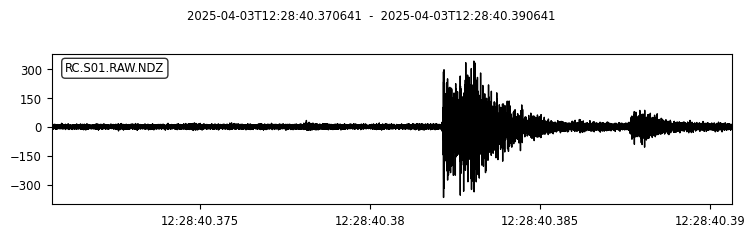

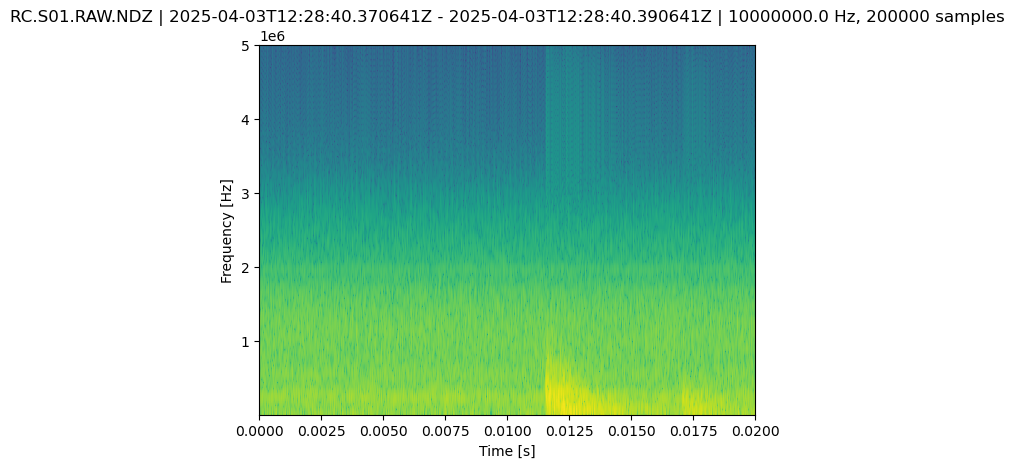

In [23]:
%matplotlib inline

filtered_trace = analysis_trace.copy()

filtered_trace.detrend('linear')
filtered_trace.detrend('demean')
filtered_trace.filter('lowpass', freq=1_500_000, corners=4, zerophase=True)
filtered_trace.plot(method='full', color='k')
filtered_trace.spectrogram(dbscale=True)

tentativo con demean, median_filter, bandpass

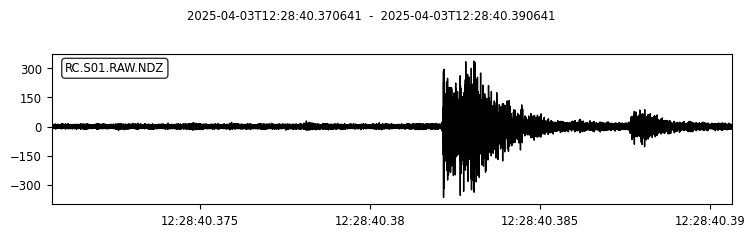

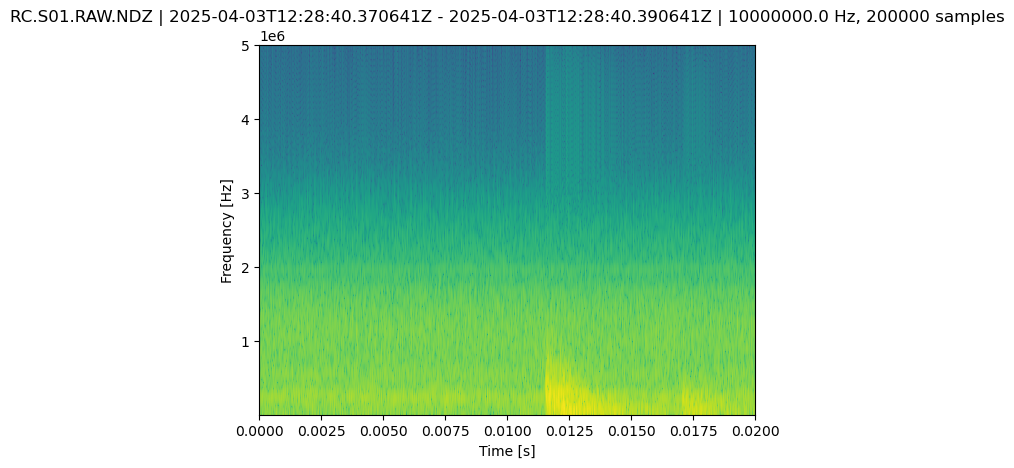

In [24]:
%matplotlib inline

filtered_trace2 = analysis_trace.copy()
filtered_trace2.detrend('linear')
filtered_trace2.detrend('demean')
filtered_trace2.filter('bandpass',freqmin=20000,freqmax=1_500_000, corners=4, zerophase=True)
filtered_trace2.plot(method='full', color='k')
filtered_trace2.spectrogram(dbscale=True)

tentativo con demean, median_filter, lowpass

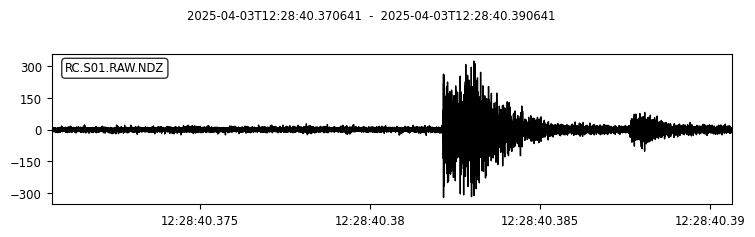

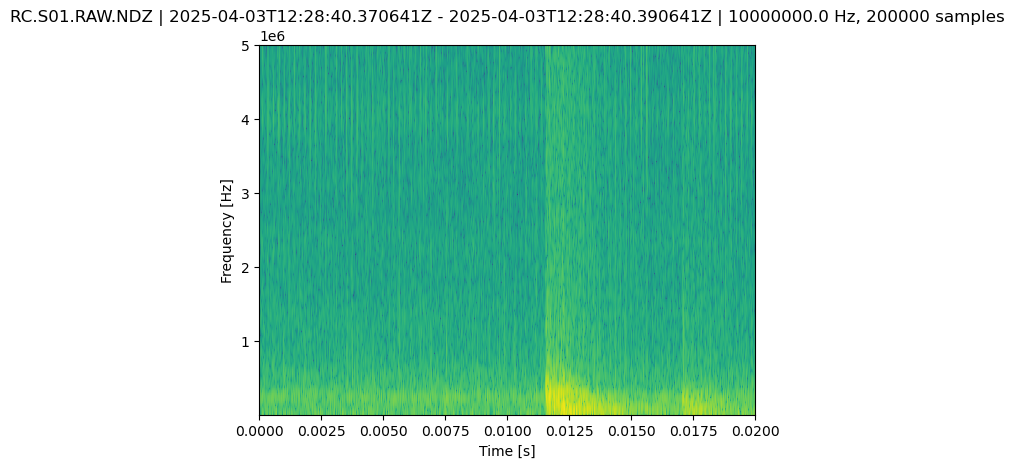

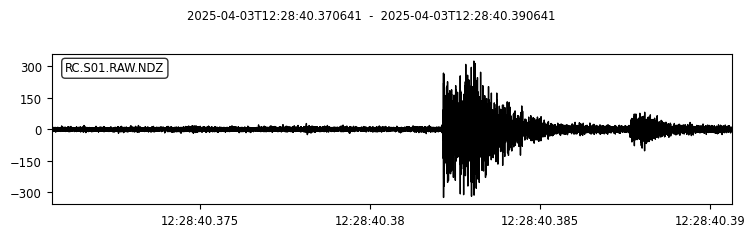

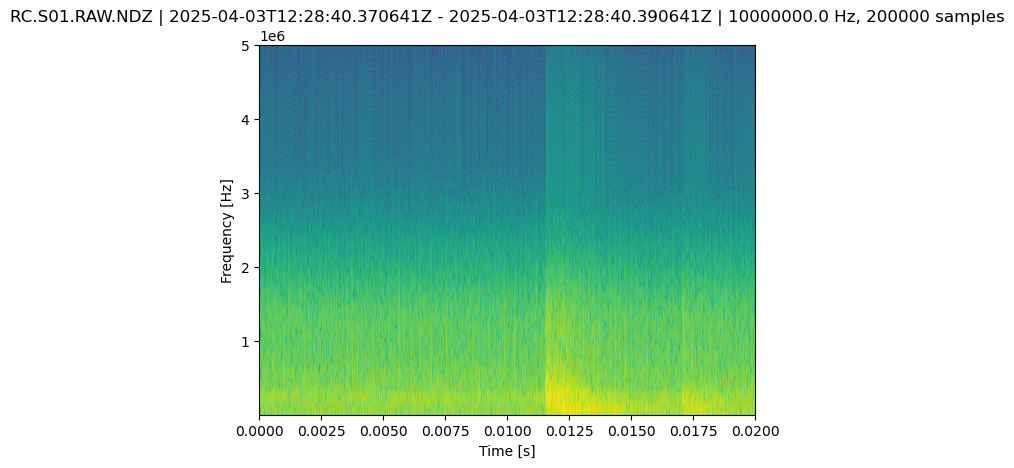

In [25]:
%matplotlib inline

from scipy.ndimage import median_filter

trigger_trace = analysis_trace.copy()
trigger_trace.detrend('linear')
trigger_trace.detrend('demean')

# finestra in campioni
win_samples = int(0.000001 * trigger_trace.stats.sampling_rate)  # es. 100 us
win_samples = max(3, win_samples | 1)  # almeno 3 e dispari

trigger_trace.data = median_filter(trigger_trace.data, size=win_samples)

trigger_trace.plot(method='full', color='k')
trigger_trace.spectrogram(dbscale=True)

trigger_trace.filter('lowpass', freq=1_500_000, corners=4, zerophase=True)
trigger_trace.plot(method='full', color='k')
trigger_trace.spectrogram(dbscale=True)

STALTA

Selected trace: RC.S01.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z
Selected trace: RC.S02.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z
Selected trace: RC.S03.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z
Selected trace: RC.S04.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z


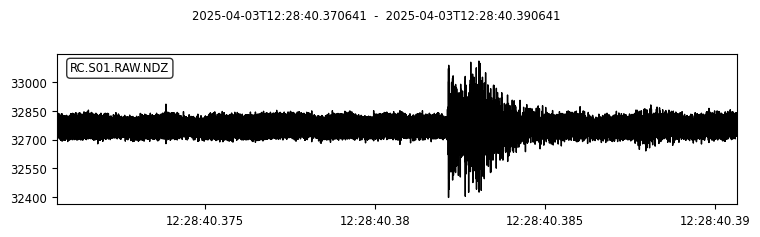

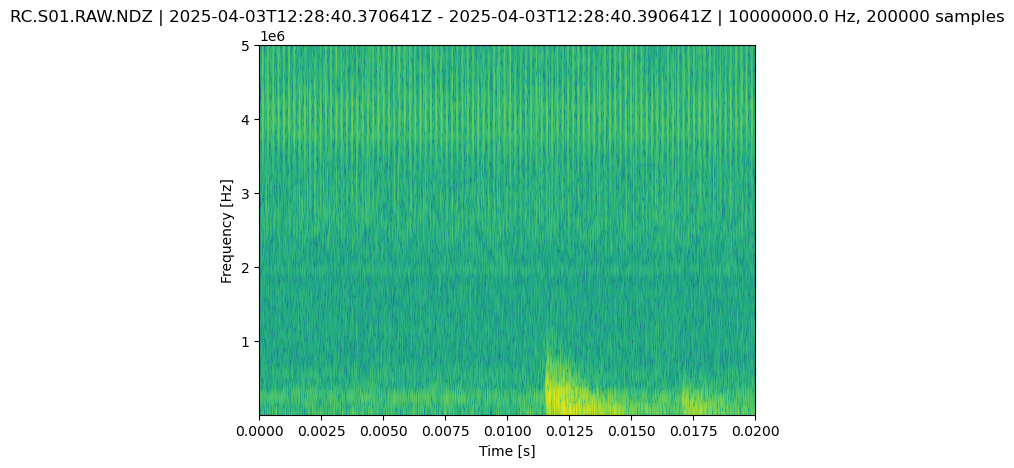

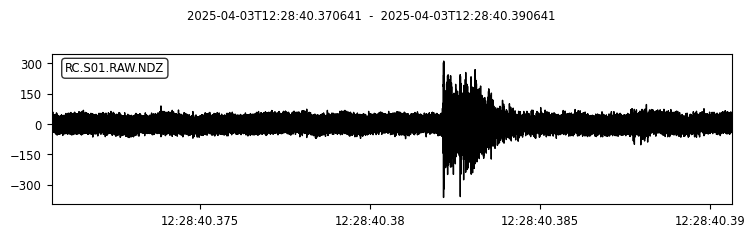

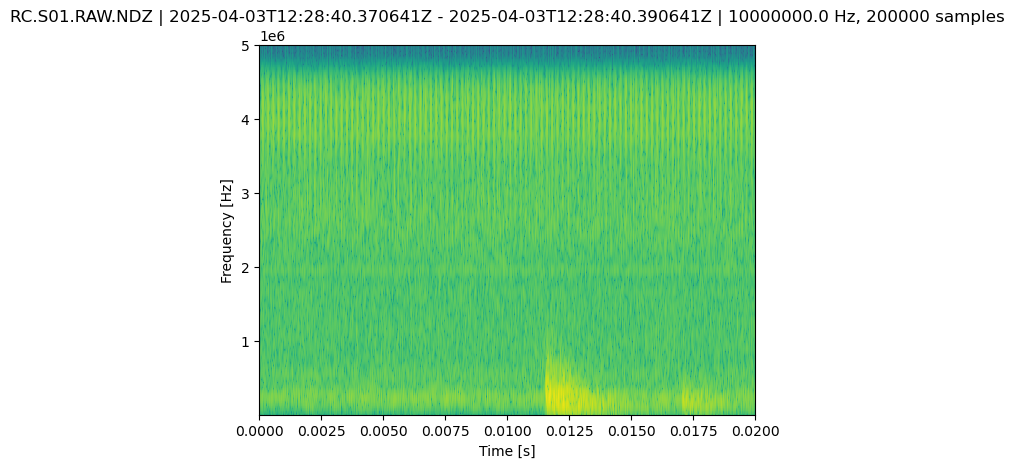

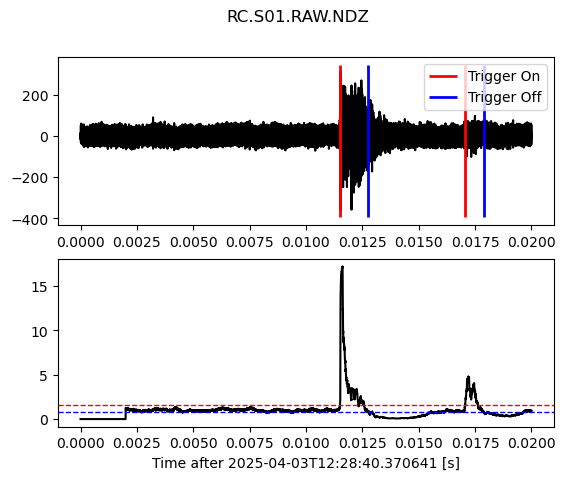

In [26]:
%matplotlib inline

tr_sta = pipeline(master_stream,pyrocko_events[0].time+0.0)

df = tr_sta.stats.sampling_rate
sta = 0.0001
lta = 0.002
cft = classic_sta_lta(tr_sta.data, int(sta * df), int(lta * df))

# %matplotlib qt
plot_trigger(tr_sta, cft, 1.6, 0.8)

PSD for signal to noise

Signal traces
Selected trace: RC.S01.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z
Selected trace: RC.S02.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z
Selected trace: RC.S03.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z
Selected trace: RC.S04.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z


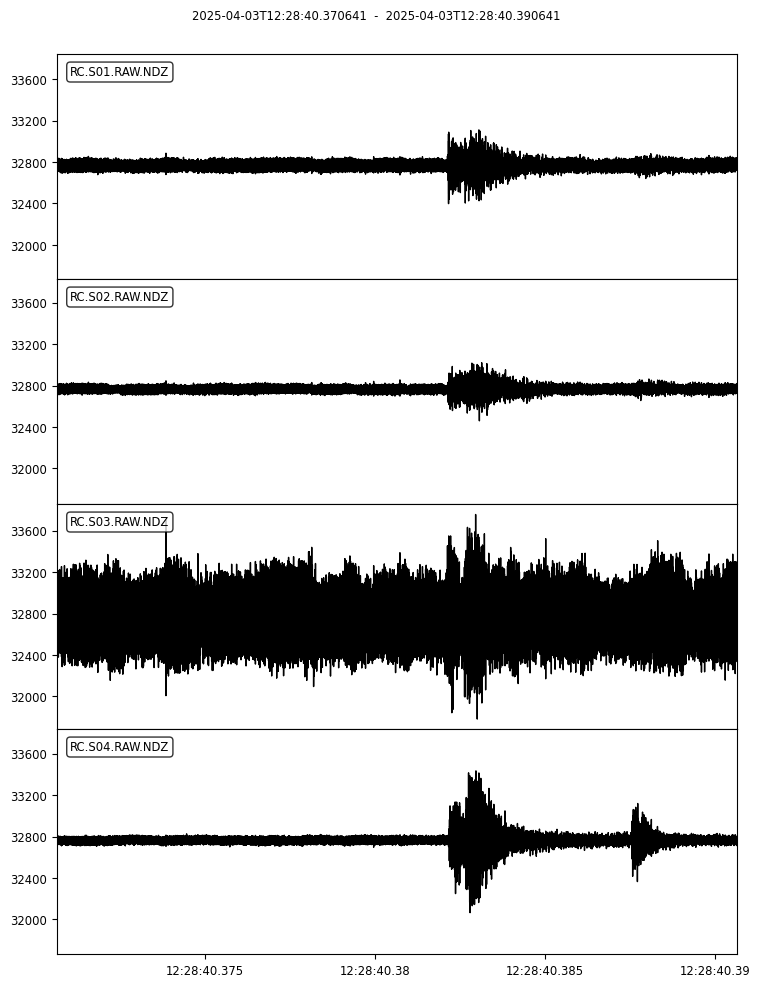

Noise traces
Selected trace: RC.S01.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z
Selected trace: RC.S02.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z
Selected trace: RC.S03.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z
Selected trace: RC.S04.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z


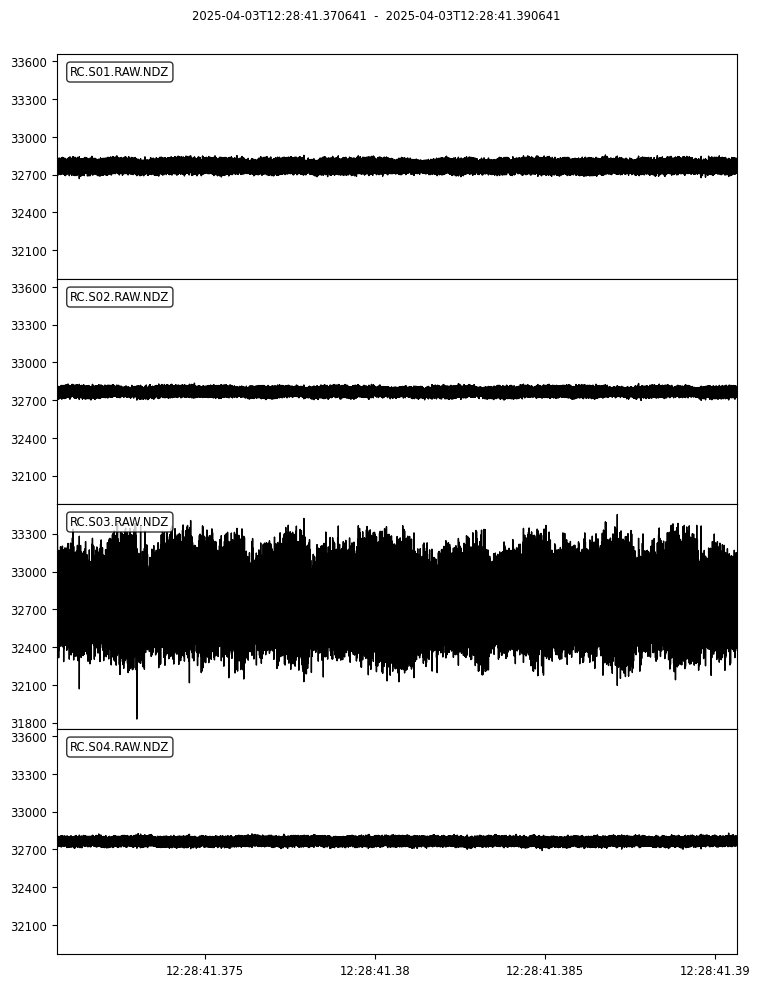

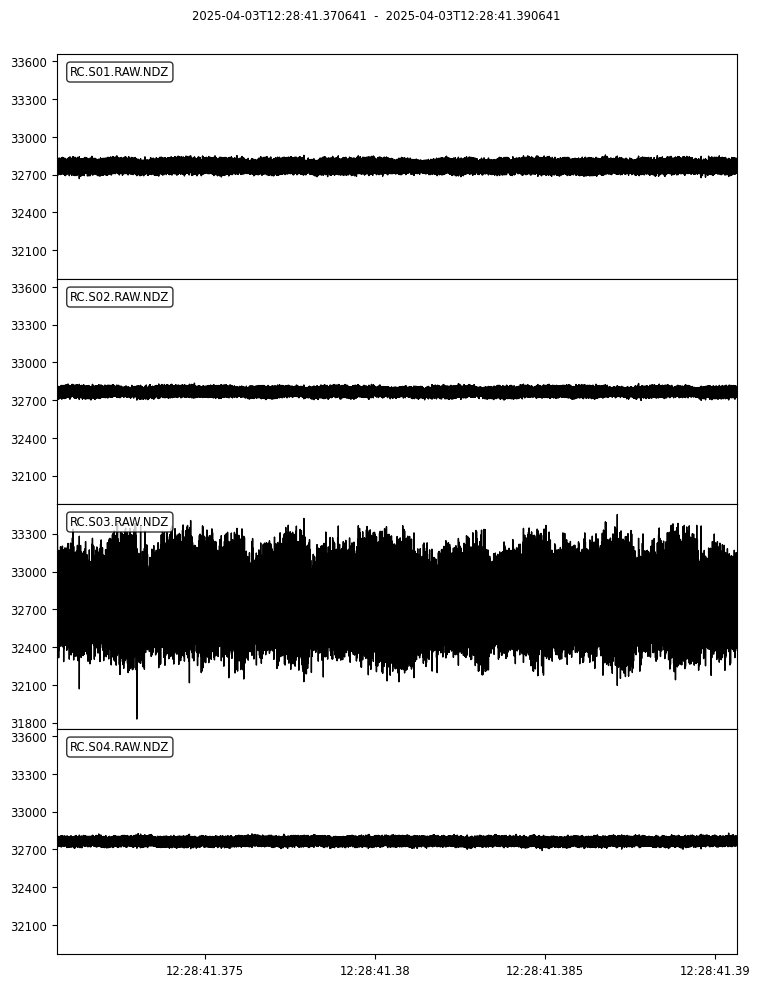

In [27]:
%matplotlib inline
print("Signal traces")
signal_trace = trace_window(master_stream, target_time, pre_seconds=0.01, post_seconds=0.01)
signal_trace.plot(method='full', color='k')

print("Noise traces")
noise_trace = trace_window(master_stream, target_time+1, pre_seconds=0.01, post_seconds=0.01)
noise_trace.plot(method='full', color='k')


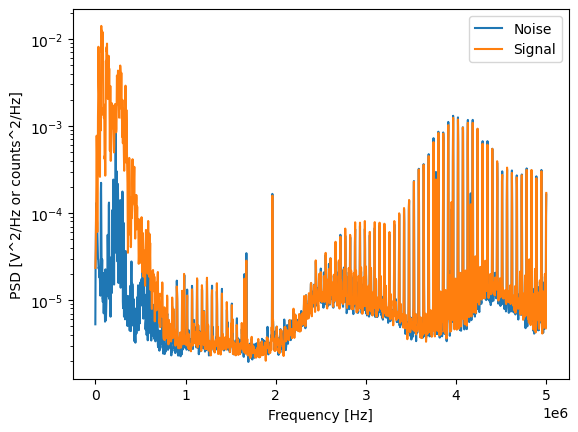

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from obspy import Stream
from scipy.signal import welch

def psd(trace, nperseg=4096):
    if isinstance(trace, Stream):
        if len(trace) == 0:
            raise ValueError('Empty stream passed to psd()')
        trace = trace[0]

    x = trace.copy()
    x.detrend("demean")
    f, pxx = welch(
        x.data.astype(np.float64),
        fs=x.stats.sampling_rate,
        nperseg=nperseg,
        scaling="density"
    )
    return f, pxx

f1, p_noise = psd(noise_trace)
f2, p_signal = psd(signal_trace)

plt.semilogy(f1, p_noise, label="Noise")
plt.semilogy(f2, p_signal, label="Signal")
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [V^2/Hz or counts^2/Hz]")
plt.legend()
plt.show()

In [29]:
from obspy.signal.trigger import trigger_onset
import numpy as np

def summarize_trigger(trace, i_on, i_off, noise_pad_s=0.0005):
    fs = trace.stats.sampling_rate
    noise_n = max(1, int(noise_pad_s * fs))
    noise_end = max(0, i_on - noise_n)
    noise_start = max(0, noise_end - (i_off - i_on))

    sig = trace.data[i_on:i_off].astype(np.float64)
    noise = trace.data[noise_start:noise_end].astype(np.float64)

    if len(sig) == 0 or len(noise) == 0:
        return None

    sig_rms = np.sqrt(np.mean(sig ** 2))
    noise_rms = np.sqrt(np.mean(noise ** 2))
    peak = np.max(np.abs(sig))
    duration_ms = 1000.0 * len(sig) / fs
    snr_db = 20.0 * np.log10(sig_rms / noise_rms) if noise_rms > 0 else np.inf
    energy_ratio = (np.sum(sig ** 2) / np.sum(noise ** 2)) if np.sum(noise ** 2) > 0 else np.inf
    impulsivity = peak / sig_rms if sig_rms > 0 else np.inf

    accepted = (duration_ms >= 0.2) and (snr_db >= 6.0) and (energy_ratio >= 3.0)

    return {
        't_on': trace.stats.starttime + i_on / fs,
        't_off': trace.stats.starttime + i_off / fs,
        'samples': len(sig),
        'duration_ms': duration_ms,
        'peak': peak,
        'sig_rms': sig_rms,
        'noise_rms': noise_rms,
        'snr_db': snr_db,
        'energy_ratio': energy_ratio,
        'impulsivity': impulsivity,
        'accepted': accepted,
    }

onsets = trigger_onset(cft, 1.6, 0.8)
print(f'Found {len(onsets)} trigger window(s)')

for i, (i_on, i_off) in enumerate(onsets):
    m = summarize_trigger(tr_sta, i_on, i_off)
    if m is None:
        continue
    verdict = 'ACCEPT' if m['accepted'] else 'REJECT'
    print(
        f"#{i} [{verdict}] {m['t_on']} -> {m['t_off']} | "
        f"dur={m['duration_ms']:.3f} ms | samples={m['samples']} | "
        f"SNR={m['snr_db']:.1f} dB | energy_ratio={m['energy_ratio']:.2f} | "
        f"peak={m['peak']:.3g} | sig_rms={m['sig_rms']:.3g} | "
        f"noise_rms={m['noise_rms']:.3g} | peak/sig_rms={m['impulsivity']:.2f}"
    )

Found 2 trigger window(s)
#0 [ACCEPT] 2025-04-03T12:28:40.382152Z -> 2025-04-03T12:28:40.383395Z | dur=1.243 ms | samples=12426 | SNR=18.3 dB | energy_ratio=67.56 | peak=363 | sig_rms=82.6 | noise_rms=10 | peak/sig_rms=4.39
#1 [ACCEPT] 2025-04-03T12:28:40.387695Z -> 2025-04-03T12:28:40.388530Z | dur=0.835 ms | samples=8354 | SNR=6.3 dB | energy_ratio=4.26 | peak=102 | sig_rms=22 | noise_rms=10.7 | peak/sig_rms=4.64


## Local Multi-Channel Association
Window all traces around the same event time, run `pipeline(...)` on each one, then cluster coincident detections across stations.

In [30]:
from obspy import Stream, UTCDateTime
from obspy.signal.trigger import classic_sta_lta, trigger_onset

association_mode = 'scan'  # 'event' or 'scan'
test_center = UTCDateTime(pyrocko_events[0].time + 0.0)
association_pre_s = 0.01
association_post_s = 0.01
scan_start = test_center
scan_end = test_center + 20.0  # only used in 'scan' mode
scan_step_s = association_pre_s + association_post_s

sta_sec = 0.0001
lta_sec = 0.002
trigger_on = 1.6
trigger_off = 0.8
coincidence_window_s = 0.002
min_stations = 3

def run_association(center_time):
    local_stream = trace_window(master_stream, center_time, pre_seconds=association_pre_s, post_seconds=association_post_s)
    print(f'Running local association on {len(local_stream)} trace(s) around {center_time}')

    detections = []
    for tr_i in local_stream:
        proc = pipeline(Stream([tr_i.copy()]), center_time, False, False)
        df = proc.stats.sampling_rate
        nsta = max(1, int(sta_sec * df))
        nlta = max(nsta + 1, int(lta_sec * df))
        if len(proc.data) <= nlta:
            continue

        cft_i = classic_sta_lta(proc.data, nsta, nlta)
        for i_on, i_off in trigger_onset(cft_i, trigger_on, trigger_off):
            t_on = proc.stats.starttime + i_on / df
            t_off = proc.stats.starttime + i_off / df
            detections.append({
                'station': proc.stats.station,
                'trace_id': proc.id,
                't_on': t_on,
                't_off': t_off,
                'center': t_on + 0.5 * (t_off - t_on),
            })

    detections.sort(key=lambda d: d['center'].timestamp)
    clusters = []
    current = []

    for det in detections:
        if not current:
            current = [det]
            continue

        dt = det['center'] - current[-1]['center']
        if abs(dt) <= coincidence_window_s:
            current.append(det)
        else:
            stations = sorted({x['station'] for x in current})
            if len(stations) >= min_stations:
                clusters.append(current)
            current = [det]

    if current:
        stations = sorted({x['station'] for x in current})
        if len(stations) >= min_stations:
            clusters.append(current)

    return detections, clusters

all_detections = []
all_clusters = []

if association_mode == 'event':
    detections, clusters = run_association(test_center)
    all_detections.extend(detections)
    all_clusters.extend(clusters)
else:
    t = scan_start
    while t < scan_end:
        detections, clusters = run_association(t)
        all_detections.extend(detections)
        all_clusters.extend(clusters)
        t = t + scan_step_s

detections = all_detections
clusters = all_clusters

print(f'Detections: {len(detections)}')
print(f'Associated clusters: {len(clusters)}')

for i, cluster in enumerate(clusters):
    stations = sorted({x['station'] for x in cluster})
    t0 = min(x['t_on'] for x in cluster)
    t1 = max(x['t_off'] for x in cluster)
    print(f'#{i}: {t0} -> {t1} | stations={stations} | n={len(cluster)}')

Selected trace: RC.S01.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z
Selected trace: RC.S02.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z
Selected trace: RC.S03.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z
Selected trace: RC.S04.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z
Running local association on 4 trace(s) around 2025-04-03T12:28:40.380641Z
Selected trace: RC.S01.RAW.NDZ | 2025-04-03T12:28:40.370641Z -> 2025-04-03T12:28:40.390641Z
Selected trace: RC.S02.RAW.NDZ | 2025-04-03T12:28:40.370641Z -> 2025-04-03T12:28:40.390641Z
Selected trace: RC.S03.RAW.NDZ | 2025-04-03T12:28:40.370641Z -> 2025-04-03T12:28:40.390641Z
Selected trace: RC.S04.RAW.NDZ | 2025-04-03T12:28:40.370641Z -> 2025-04-03T12:28:40.390641Z
Selected trace: RC.S01.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z
Selected trace: RC.S02.RAW.NDZ | 2025-04-03T12:28:19.189000Z -> 2025-04-03T12:38:19.367688Z
Selec

## Export Clusters
Write one CSV row per detection so the cluster list can be reloaded later.

In [35]:
from pathlib import Path
import csv

export_dir = Path.cwd() / 'cluster_exports'
export_dir.mkdir(parents=True, exist_ok=True)
export_path = export_dir / 'clusters.csv'

with export_path.open('w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['cluster_idx', 'detection_idx', 'station', 'trace_id', 't_on', 't_off', 'center'])
    for cluster_idx, cluster in enumerate(clusters):
        for detection_idx, det in enumerate(cluster):
            writer.writerow([
                cluster_idx,
                detection_idx,
                det['station'],
                det['trace_id'],
                det['t_on'].isoformat(),
                det['t_off'].isoformat(),
                det['center'].isoformat(),
            ])

print(f'Wrote {export_path}')
print('You can reload it later and rebuild Pyrocko markers/events from these rows.')

Wrote g:\Il mio Drive\Stefano\Git_folder\data_reduction\richter\insite2obspy\cluster_exports\clusters.csv
You can reload it later and rebuild Pyrocko markers/events from these rows.


## Cluster Visualization
Plot one associated cluster as a waveform window and optionally open it in Snuffler.

In [31]:
print("there are " + str(len(clusters)) + " clusters")

there are 11 clusters


In [32]:
UTCDateTime(pyrocko_events[1].time)

2025-04-03T12:28:52.209319Z

Cluster #0: 2025-04-03T12:28:40.380152Z -> 2025-04-03T12:28:40.389404Z | stations=['S01', 'S02', 'S03', 'S04'] | traces=4
Events in window: [0]


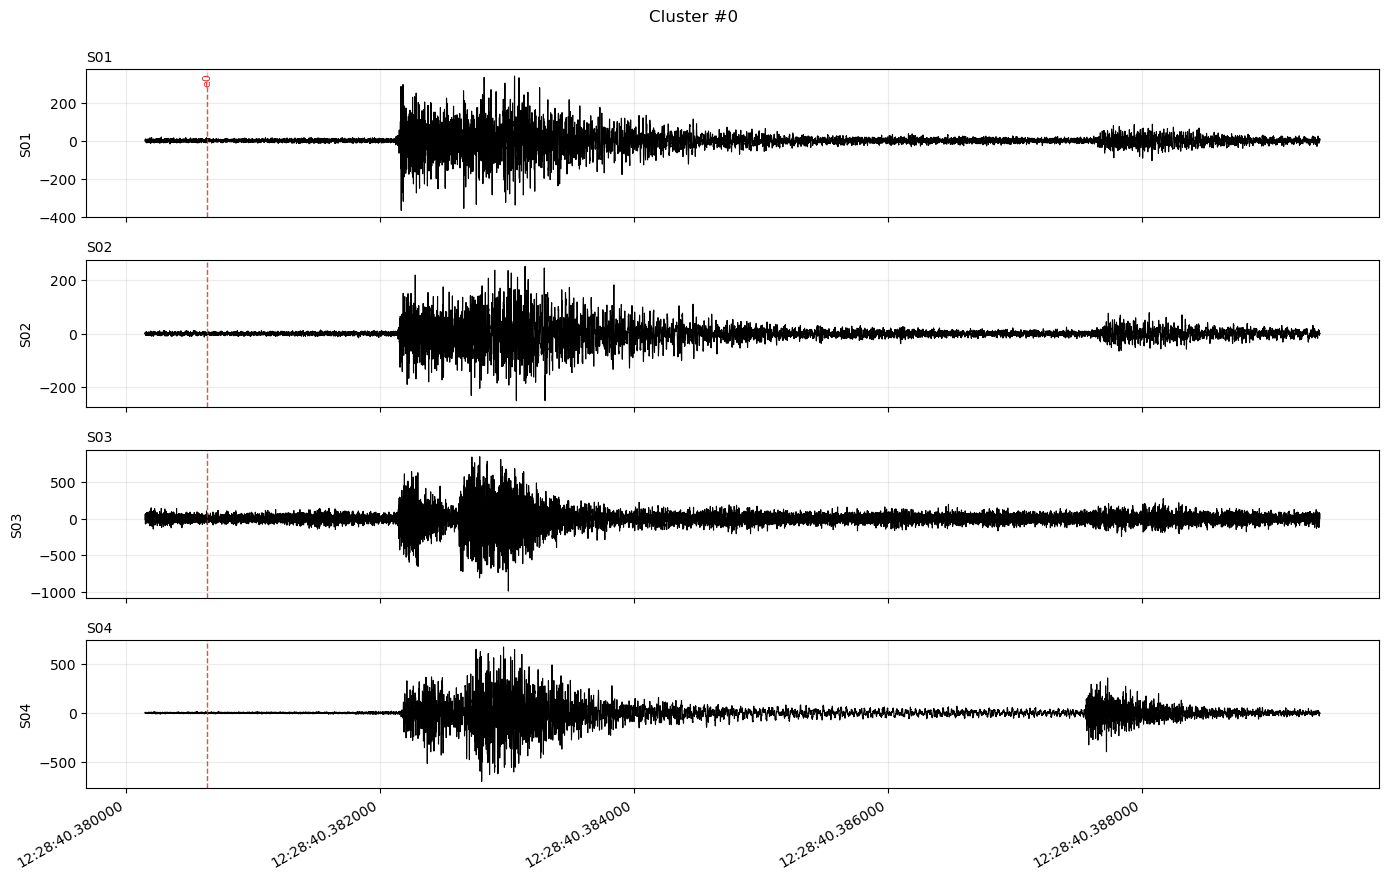

Cluster #1: 2025-04-03T12:28:40.385563Z -> 2025-04-03T12:28:40.394622Z | stations=['S01', 'S02', 'S03', 'S04'] | traces=4
Events in window: []


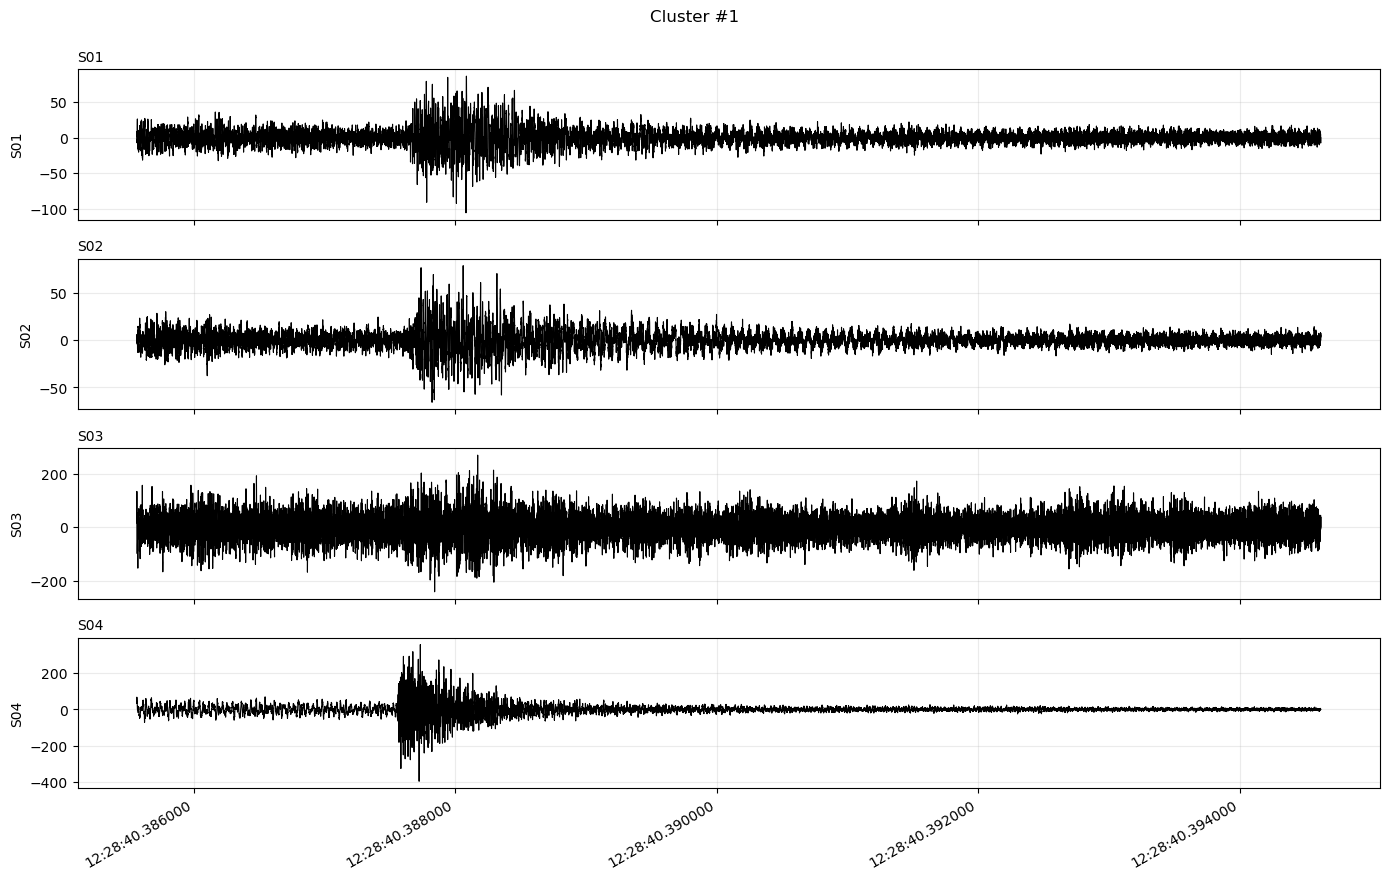

Nearby events around cluster start: [(0, UTCDateTime(2025, 4, 3, 12, 28, 40, 380641))]
Cluster #2: 2025-04-03T12:28:40.516206Z -> 2025-04-03T12:28:40.525592Z | stations=['S01', 'S02', 'S03'] | traces=3
Events in window: []


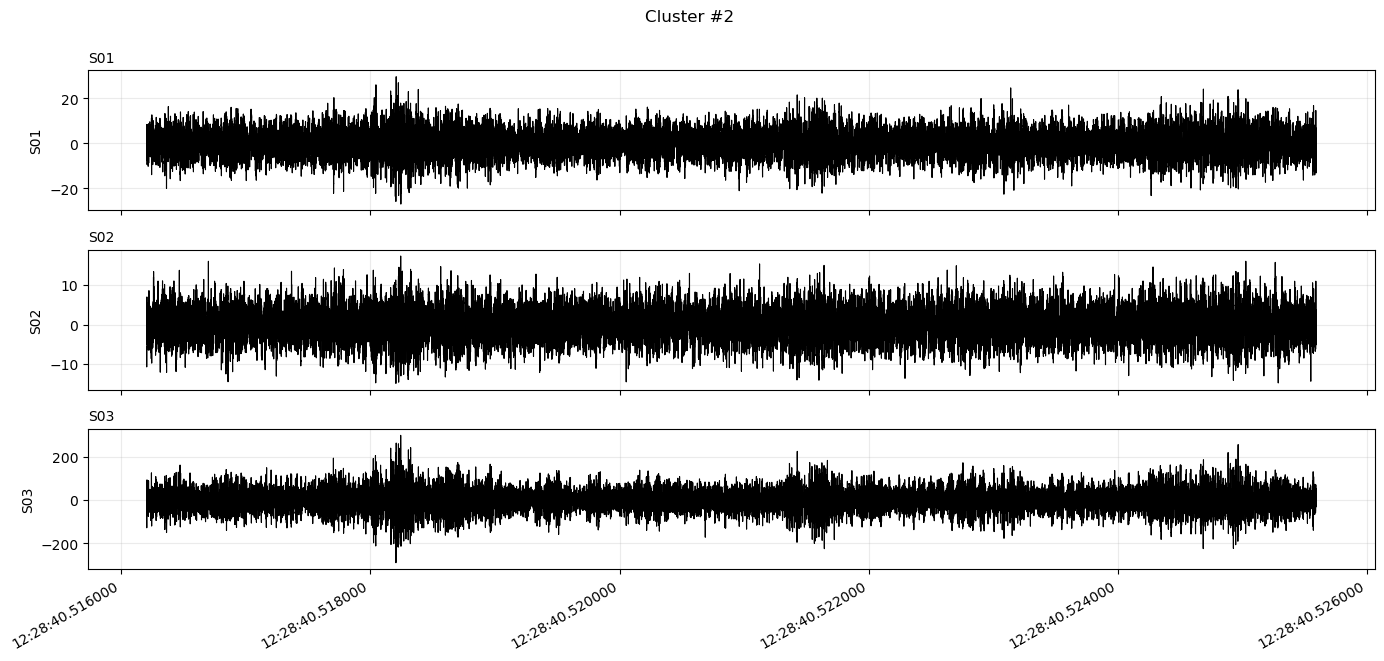

Nearby events around cluster start: [(0, UTCDateTime(2025, 4, 3, 12, 28, 40, 380641))]
Cluster #3: 2025-04-03T12:28:45.690641Z -> 2025-04-03T12:28:45.701348Z | stations=['S01', 'S02', 'S03', 'S04'] | traces=4
Events in window: []


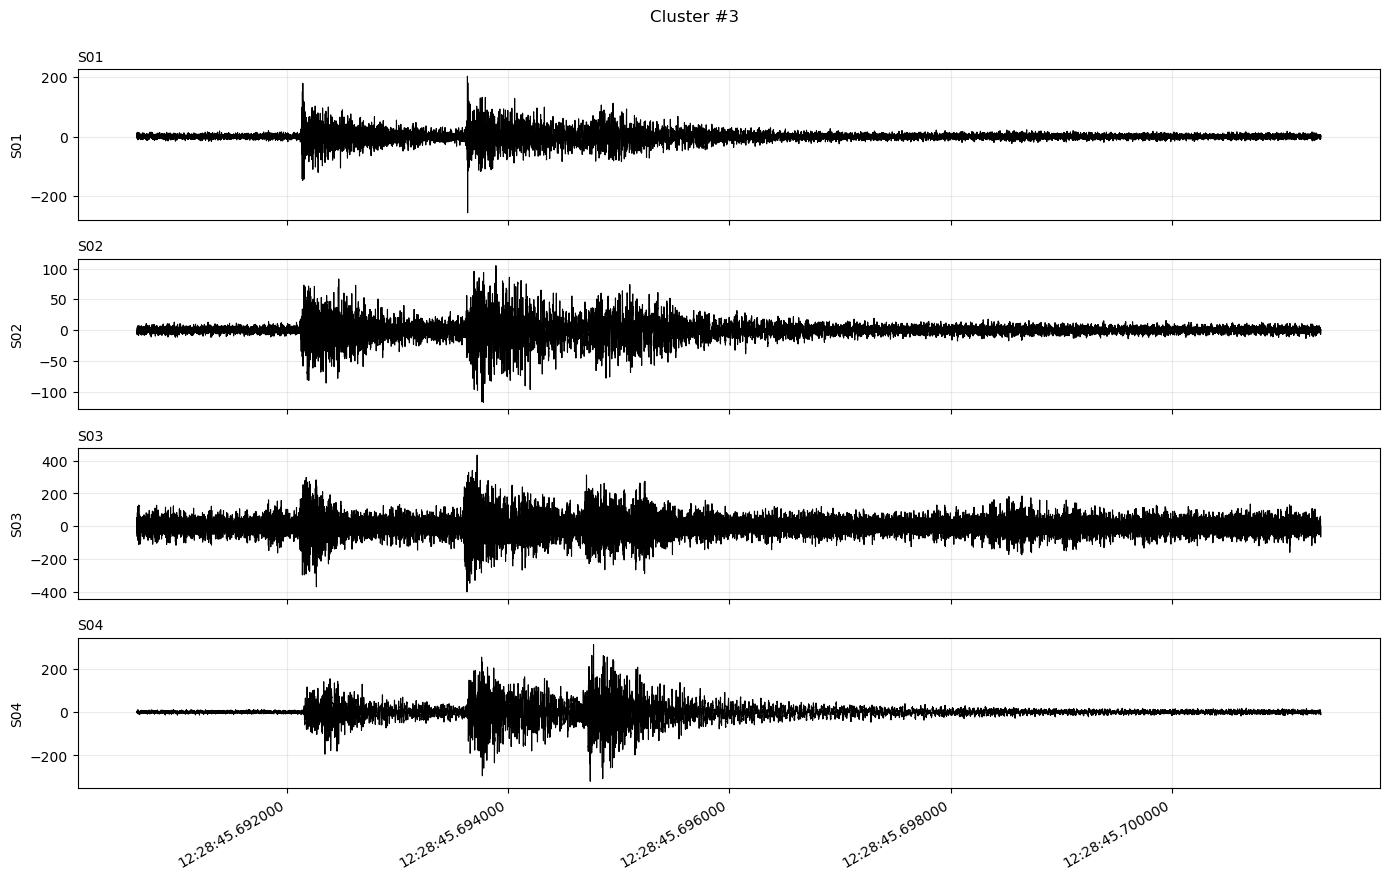

Nearby events around cluster start: []
Cluster #4: 2025-04-03T12:28:48.386550Z -> 2025-04-03T12:28:48.395557Z | stations=['S01', 'S02', 'S03'] | traces=3
Events in window: []


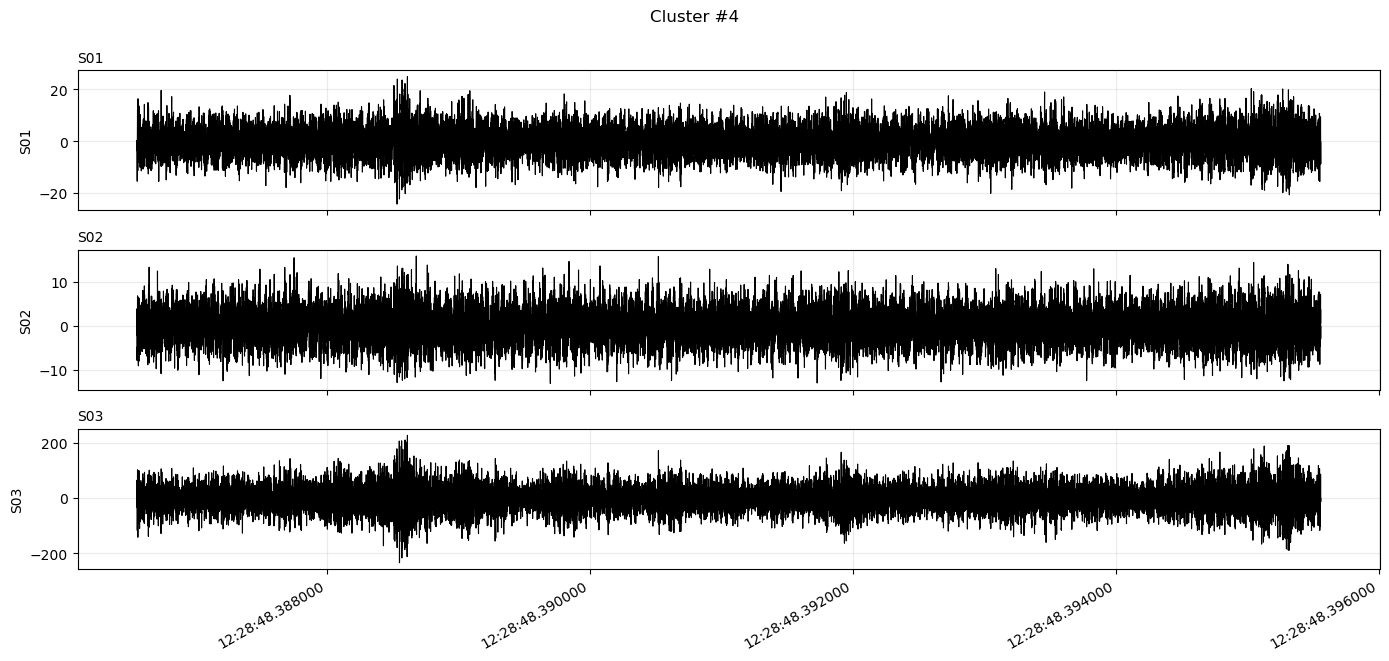

Nearby events around cluster start: []
Cluster #5: 2025-04-03T12:28:48.826083Z -> 2025-04-03T12:28:48.836641Z | stations=['S01', 'S02', 'S03', 'S04'] | traces=4
Events in window: []


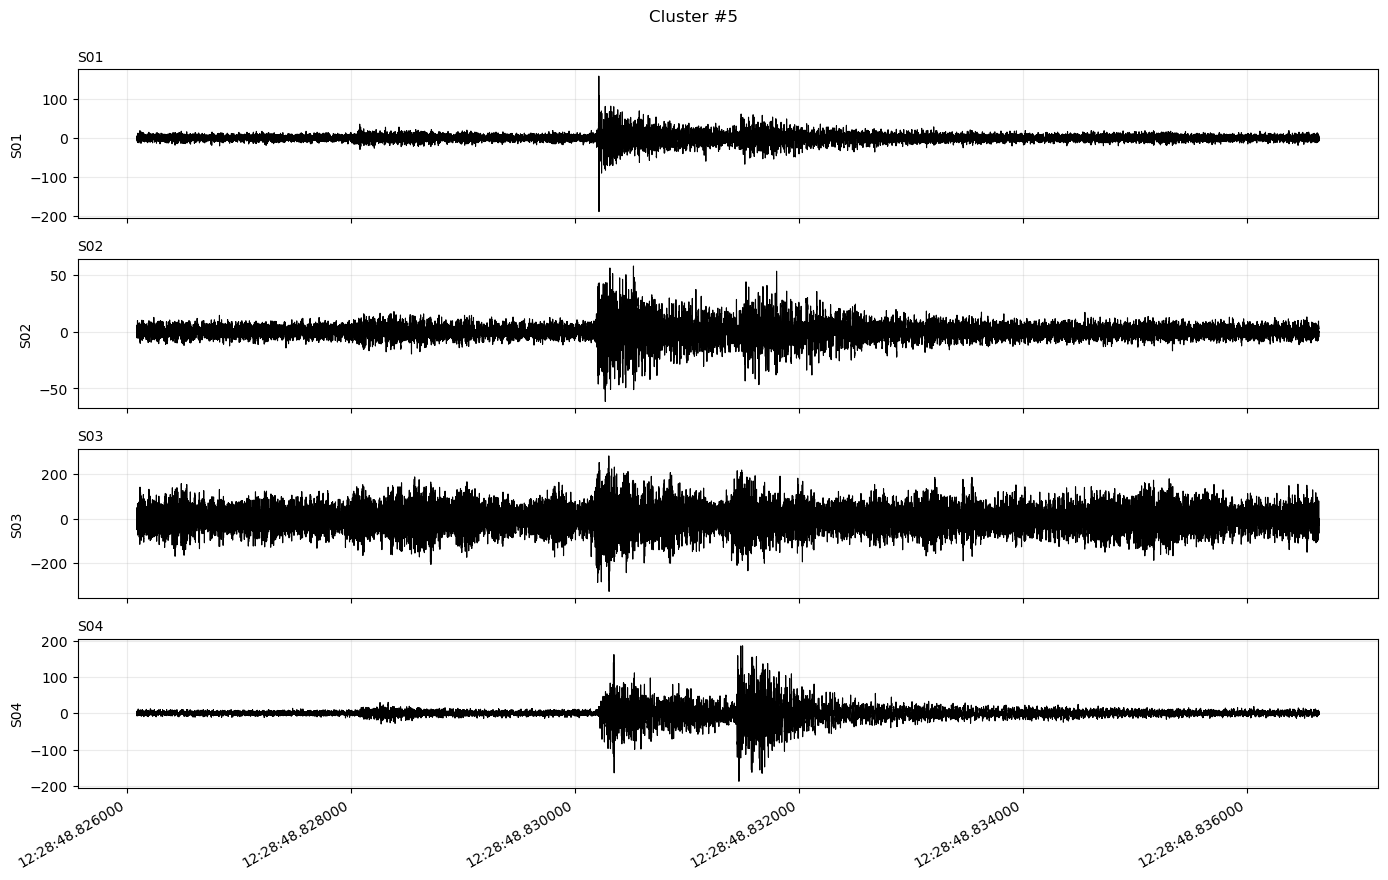

Nearby events around cluster start: []
Cluster #6: 2025-04-03T12:28:52.646431Z -> 2025-04-03T12:28:52.656022Z | stations=['S01', 'S02', 'S03'] | traces=3
Events in window: []


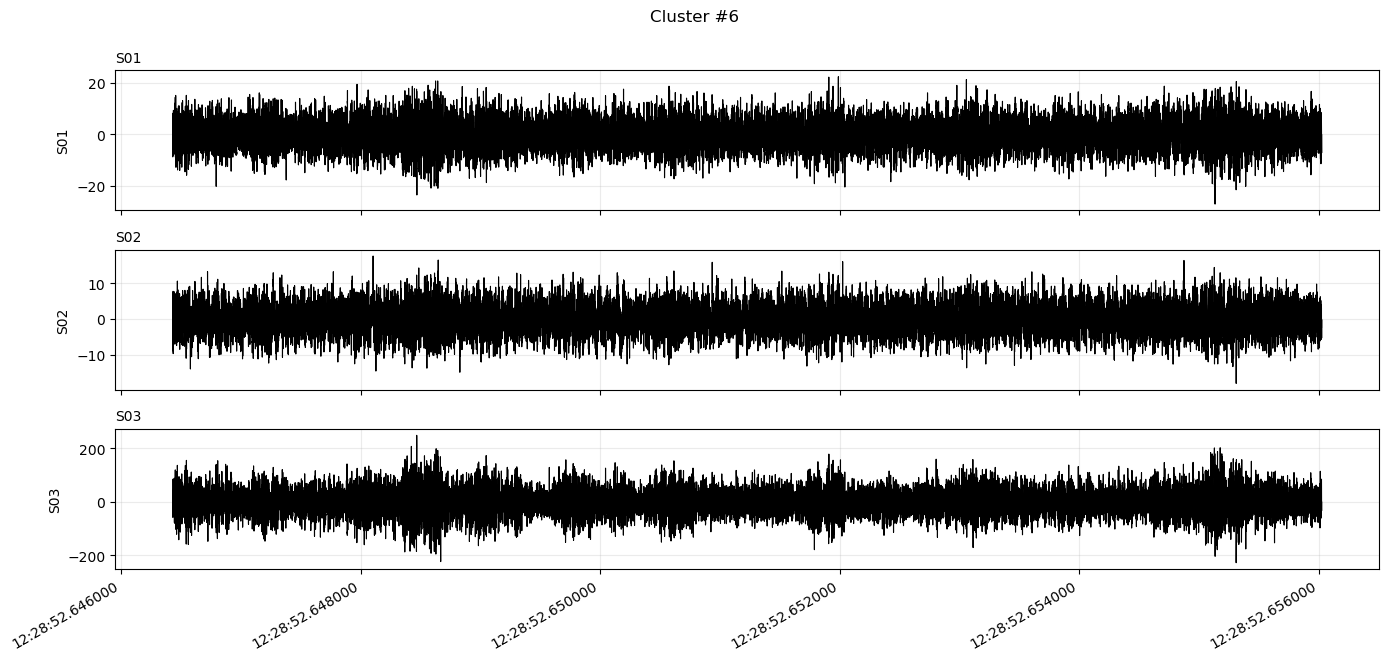

Nearby events around cluster start: [(1, UTCDateTime(2025, 4, 3, 12, 28, 52, 209319))]
Cluster #7: 2025-04-03T12:28:56.511392Z -> 2025-04-03T12:28:56.521021Z | stations=['S01', 'S02', 'S03', 'S04'] | traces=4
Events in window: [2, 3, 4]


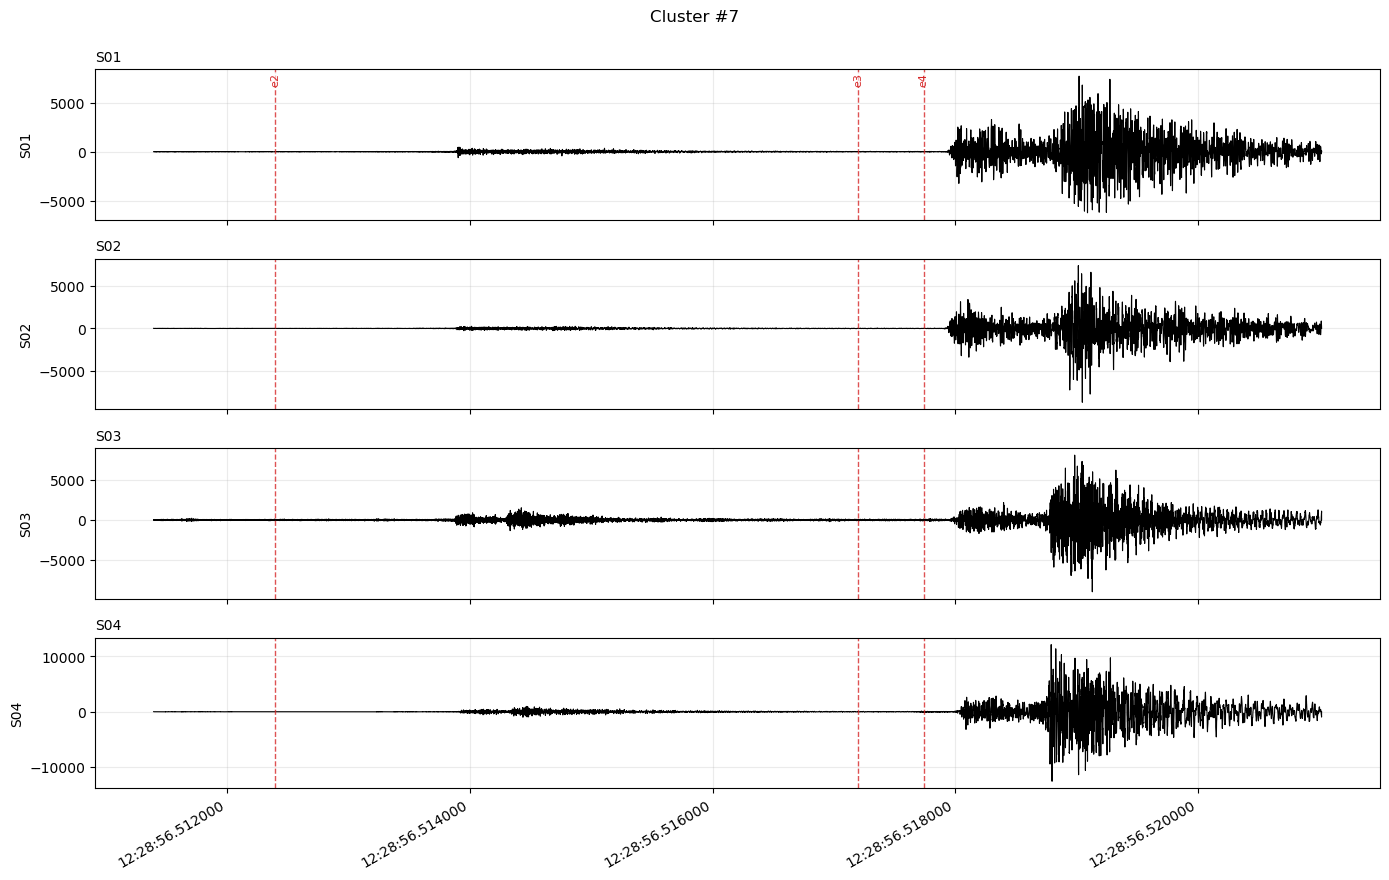

Cluster #8: 2025-04-03T12:28:56.515938Z -> 2025-04-03T12:28:56.525616Z | stations=['S01', 'S02', 'S03', 'S04'] | traces=4
Events in window: [3, 4]


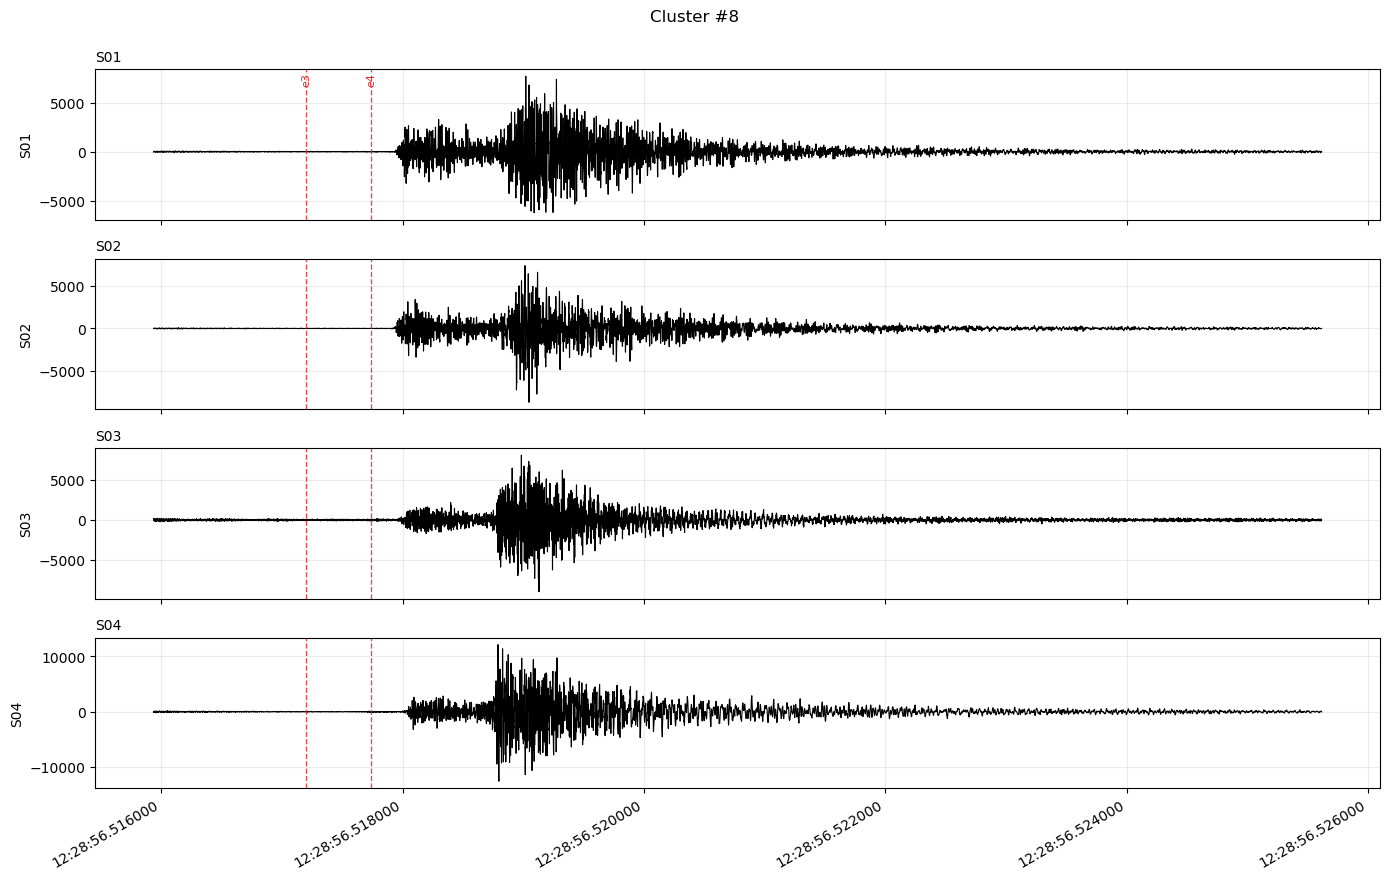

Cluster #9: 2025-04-03T12:28:58.076094Z -> 2025-04-03T12:28:58.085533Z | stations=['S01', 'S02', 'S03', 'S04'] | traces=4
Events in window: []


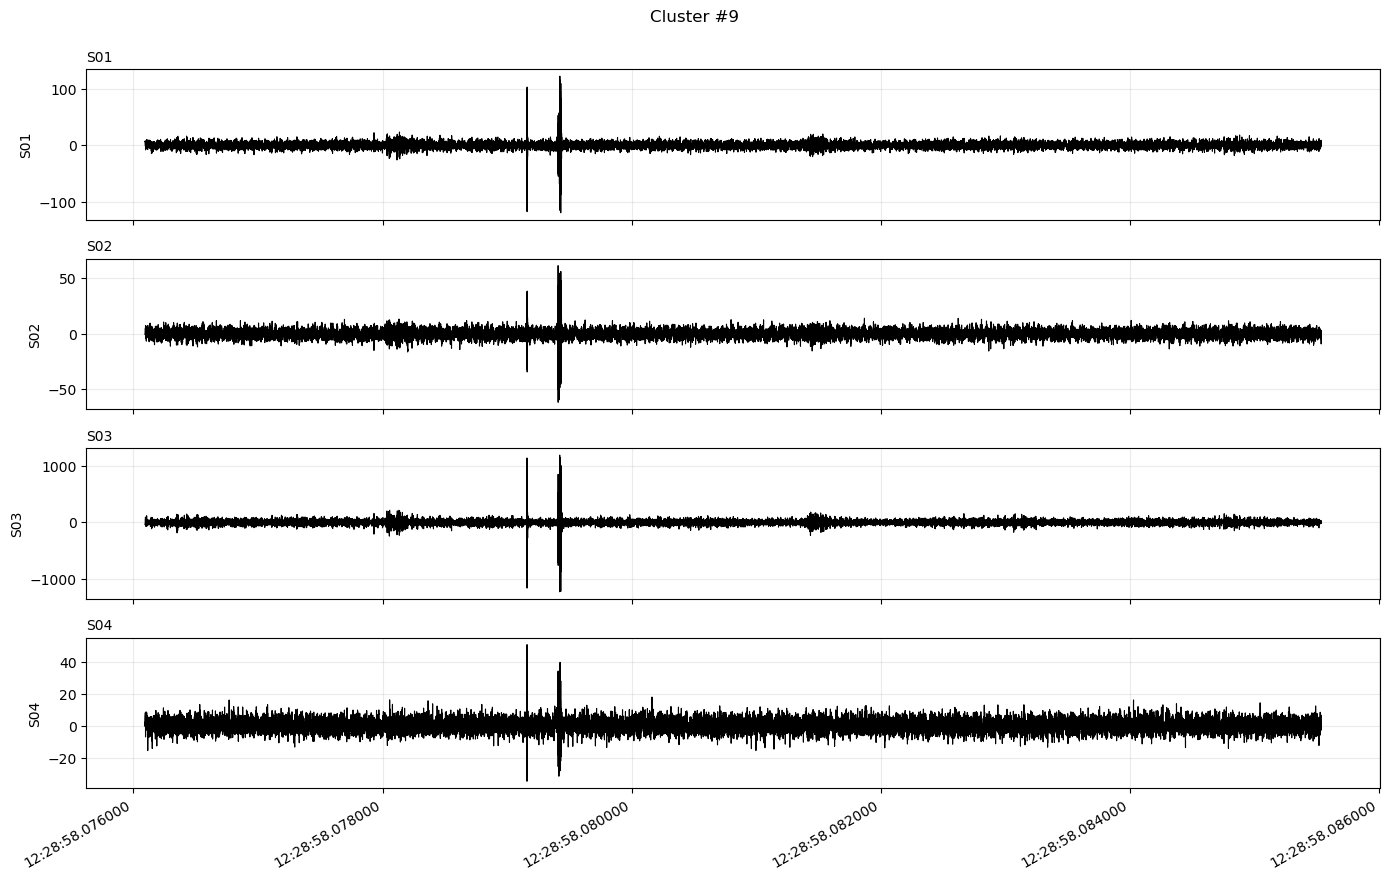

Nearby events around cluster start: []
Cluster #10: 2025-04-03T12:28:59.771989Z -> 2025-04-03T12:28:59.783292Z | stations=['S01', 'S02', 'S03', 'S04'] | traces=4
Events in window: []


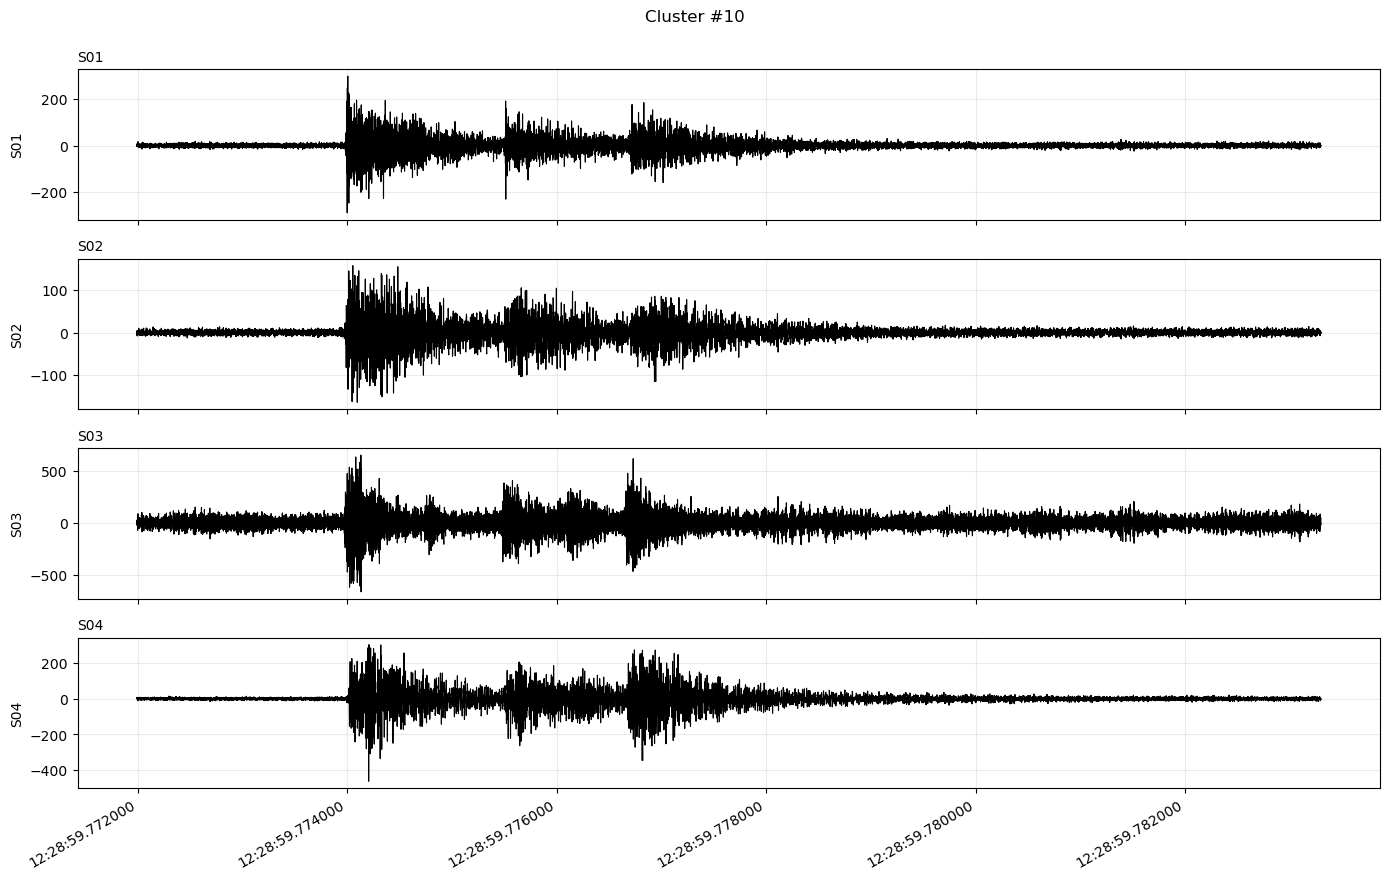

Nearby events around cluster start: []


In [33]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

for cluster_idx, cluster in enumerate(clusters):
    t0 = min(x['t_on'] for x in cluster) - 0.002
    t1 = max(x['t_off'] for x in cluster) + 0.006
    stations = sorted({x['station'] for x in cluster})
    event_indices_in_window = [
        (i, ev) for i, ev in enumerate(pyrocko_events)
        if t0 <= UTCDateTime(ev.time) <= t1
    ]

    vis_stream = stream_window(master_stream, t0, t1)
    vis_stream = Stream([tr for tr in vis_stream if tr.stats.station in stations])
    vis_stream.detrend('linear')
    vis_stream.detrend('demean')
    vis_stream.filter('bandpass', freqmin=10000, freqmax=1_500_000, corners=4, zerophase=True)

    print(f'Cluster #{cluster_idx}: {t0} -> {t1} | stations={stations} | traces={len(vis_stream)}')
    print(f'Events in window: {[i for i, _ in event_indices_in_window]}')

    if len(vis_stream) == 0:
        continue

    fig, axes = plt.subplots(len(vis_stream), 1, sharex=True, figsize=(14, 2.2 * len(vis_stream)))
    if len(vis_stream) == 1:
        axes = [axes]

    for ax, tr in zip(axes, vis_stream):
        x = tr.times(type='matplotlib')
        ax.plot_date(x, tr.data, '-', color='black', linewidth=0.8)
        ax.set_ylabel(tr.stats.station)
        ax.set_title(tr.stats.station, loc='left', fontsize=10)
        ax.grid(True, alpha=0.25)

        for event_idx, ev in event_indices_in_window:
            ev_time = mdates.date2num(UTCDateTime(ev.time).datetime)
            ax.axvline(ev_time, color='tab:red', linestyle='--', linewidth=1.0, alpha=0.8)

    for event_idx, ev in event_indices_in_window:
        ev_time = mdates.date2num(UTCDateTime(ev.time).datetime)
        axes[0].text(
            ev_time, 0.98, f'e{event_idx}',
            transform=axes[0].get_xaxis_transform(),
            rotation=90,
            va='top', ha='center',
            color='tab:red',
            fontsize=8,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.6, pad=0.2),
        )

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S.%f'))
    fig.autofmt_xdate()
    fig.suptitle(f'Cluster #{cluster_idx}', y=0.995)
    plt.tight_layout()
    plt.show()

    if not event_indices_in_window:
        nearby = [(i, UTCDateTime(ev.time)) for i, ev in enumerate(pyrocko_events) if abs(UTCDateTime(ev.time) - t0) < 1.0]
        print(f'Nearby events around cluster start: {nearby}')
